# Machine learning course report
## Prepared by:
## Sun Yufei
## 2023-01-17

The project is divided into several sections:
- Introduction
- Dataset Processing
    - Import dataset
    - Check missing values and data type
    - Get list of categorical variables
    - Visualization of the Data
- Select variables
- Model Building
    - Model 1 Regression Tree
    - Model 2 Random Forest
    - Model 3 XGBRegressor
- Results and Conclusions

# Diamond Regression

<h1 style='background:#6c8078; border:0; color:black'><center>Introduction</center></h1>

## 1 Introduction

In this regression part, the task is to apply three ML algorithms to build a model explaining the dataset of diamonds based on the training sample and generate predictions of prices for all observations from the test sample.

This classic dataset contains the prices and other attributes of almost 54,000 diamonds. There are 9 dependent variables in total, they are carat, cut, color, clarity, depth, table, x, y and z. The dependent variable is **price** - in US dollars (\$326-\$18,823)This is the target column containing tags for the features.

In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import random
import csv
import statistics
import statsmodels.api as sm

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.pyplot as plt

import seaborn as sns

from sklearn import datasets # to download datasest: Boston
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import plot_tree
from sklearn import metrics
from sklearn.preprocessing import scale
from sklearn.metrics import mean_squared_error
from sklearn import tree
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')

<h1 style='background:#6c8078; border:0; color:black'><center>Dataset Processing</center></h1>

## 2 Dataset Processing

**Feature description**:

**price** price in US dollars (\$326--\$18,823)This is the target column containing tags for the features. 

**The 4 Cs of Diamonds:-**

**carat (0.2--5.01)**
The carat is the diamond’s physical weight measured in metric carats.  One carat equals 1/5 gram and is subdivided into 100 points. Carat weight is the most objective grade of the 4Cs. 

**cut (Fair, Good, Very Good, Premium, Ideal)**
In determining the quality of the cut, the diamond grader evaluates the cutter’s skill in the fashioning of the diamond. The more precise the diamond is cut, the more captivating the diamond is to the eye.  

**color, from J (worst) to D (best)**
The colour of gem-quality diamonds occurs in many hues. In the range from colourless to light yellow or light brown. Colourless diamonds are the rarest. Other natural colours (blue, red, pink for example) are known as "fancy,” and their colour grading is different than from white colorless diamonds.  

**clarity (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))**
Diamonds can have internal characteristics known as inclusions or external characteristics known as blemishes. Diamonds without inclusions or blemishes are rare; however, most characteristics can only be seen with magnification.  

**Dimensions**

**x length in mm (0--10.74)**

**y width in mm (0--58.9)**

**z depth in mm (0--31.8)**

**depth total depth percentage = z / mean(x, y) = 2 * z / (x + y) (43--79)**
The depth of the diamond is its height (in millimetres) measured from the culet (bottom tip) to the table (flat, top surface).

**table width of the top of the diamond relative to widest point (43--95)**

A diamond's table refers to the flat facet of the diamond seen when the stone is face up. The main purpose of a diamond table is to refract entering light rays and allow reflected light rays from within the diamond to meet the observer’s eye. The ideal table cut diamond will give the diamond stunning fire and brilliance.

### 2.1 Import dataset

In [4]:
# import dataset
data = pd.read_csv('C:/Users/Admin/Desktop/data/diamonds.csv')
## drop variable 'id'
data = data.drop(columns=['ID'])
## view dataset
data.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53940 non-null  float64
 1   cut      53940 non-null  object 
 2   color    53940 non-null  object 
 3   clarity  53940 non-null  object 
 4   depth    53940 non-null  float64
 5   table    53940 non-null  float64
 6   price    53940 non-null  int64  
 7   x        53940 non-null  float64
 8   y        53940 non-null  float64
 9   z        53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


### 2.2 Check missing values and data type

Missing value

In [6]:
# pd.isnull(df).any()
pd.isnull(data).sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
price      0
x          0
y          0
z          0
dtype: int64

As we can there is no any missing value fortunately.

Data type

In [7]:
# check the type of variables
type_of_columns = data.dtypes

print(type_of_columns)

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
price        int64
x          float64
y          float64
z          float64
dtype: object


In [8]:
type_of_columns.describe()

count          10
unique          3
top       float64
freq            6
dtype: object

Outliers

In [9]:
# Dropping dimentionless diamonds
data = data.drop(data[data["x"]==0].index)
data = data.drop(data[data["y"]==0].index)
data = data.drop(data[data["z"]==0].index)
data.shape

(53920, 10)

In [10]:
# Dropping the outliers. 
data = data[(data["depth"]<75)&(data["depth"]>45)]
data = data[(data["table"]<80)&(data["table"]>40)]
data = data[(data["x"]<30)]
data = data[(data["y"]<30)]
data = data[(data["z"]<30)&(data["z"]>2)]
data.shape

(53907, 10)

### 2.3 Get list of categorical variables

In [11]:
data['cut'] = data['cut'].replace(["Fair","Good","Ideal","Premium","Very Good"], [1, 2, 3, 4 ,5])

In [12]:
data['color'] = data['color'].replace(["D","E","F","G","H","I","J"], [1, 2, 3, 4 ,5, 6, 7])

In [13]:
data['clarity'] = data['clarity'].replace(["I1","IF","SI1","SI2","VS1","VS2","VVS1","VVS2"], [1, 2, 3, 4, 5, 6, 7, 8])

In [14]:
data['color'] = data['color'].astype(np.float64)
data['price'] = data['price'].astype(np.float64)
data['clarity'] = data['clarity'].astype(np.float64)
data['cut'] = data['cut'].astype(np.float64)

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 53907 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53907 non-null  float64
 1   cut      53907 non-null  float64
 2   color    53907 non-null  float64
 3   clarity  53907 non-null  float64
 4   depth    53907 non-null  float64
 5   table    53907 non-null  float64
 6   price    53907 non-null  float64
 7   x        53907 non-null  float64
 8   y        53907 non-null  float64
 9   z        53907 non-null  float64
dtypes: float64(10)
memory usage: 4.5 MB


### 2.4 Visualization of the Data

It starts from 'carat' variable. We can look at the graph to see distribution better.
There are some features with datapoint that are far from the rest of the dataset which will affect the outcome of our regression model.

* "x", "y" and "z" have some dimensional outlies in our dataset that needs to be eliminated.
* The "depth" should be capped but we must examine the regression line to be sure.
* The "table" should be capped.
* The "carat" should be capped too.

Text(0.5, 1.0, 'Regression Line on Price vs carat')

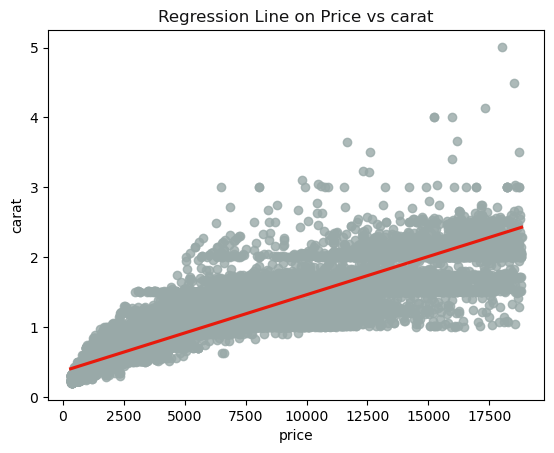

In [16]:
ax = sns.regplot(x="price", y="carat", data=data, fit_reg=True, scatter_kws={"color": "#99a9a8"}, line_kws={"color": "#e81a0c"})
ax.set_title("Regression Line on Price vs carat", color="#131314")

Text(0.5, 1.0, 'Regression Line on Price vs x')

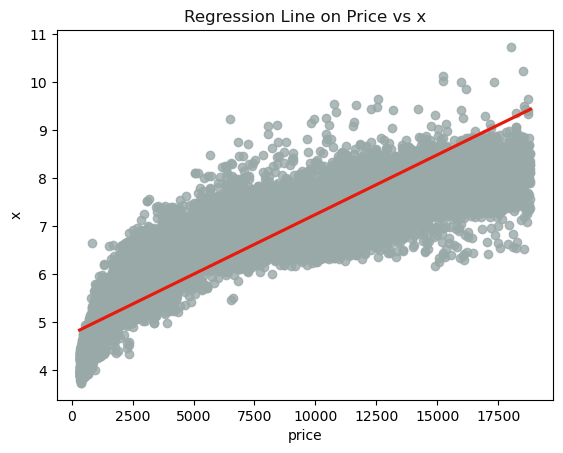

In [17]:
ax = sns.regplot(x="price", y="x", data=data, fit_reg=True, scatter_kws={"color": "#99a9a8"}, line_kws={"color": "#e81a0c"})
ax.set_title("Regression Line on Price vs x", color="#131314")

Text(0.5, 1.0, 'Regression Line on Price vs y')

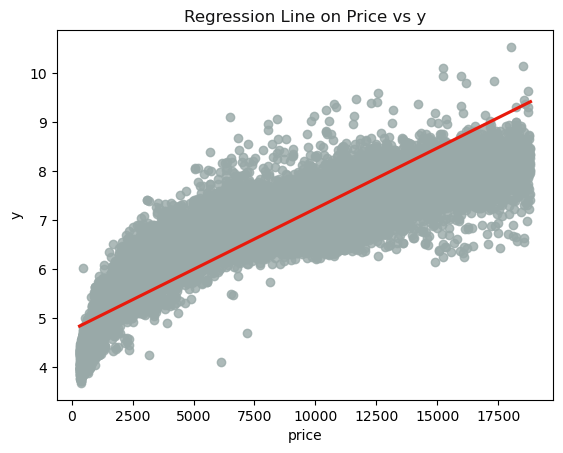

In [18]:
ax = sns.regplot(x="price", y="y", data=data, fit_reg=True, scatter_kws={"color": "#99a9a8"}, line_kws={"color": "#e81a0c"})
ax.set_title("Regression Line on Price vs y", color="#131314")

Text(0.5, 1.0, 'Regression Line on Price vs z')

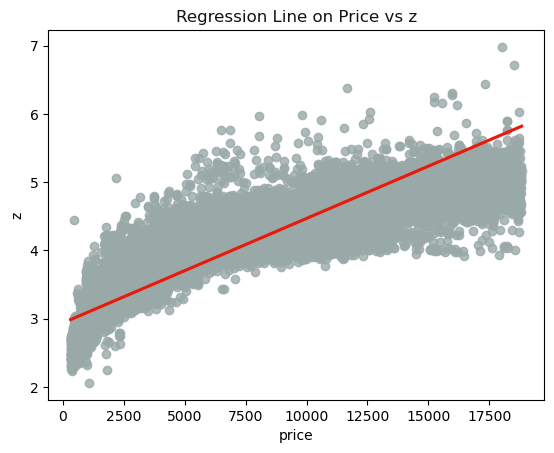

In [19]:
ax = sns.regplot(x="price", y="z", data=data, fit_reg=True, scatter_kws={"color": "#99a9a8"}, line_kws={"color": "#e81a0c"})
ax.set_title("Regression Line on Price vs z", color="#131314")

Text(0.5, 1.0, 'Regression Line on Price vs depth')

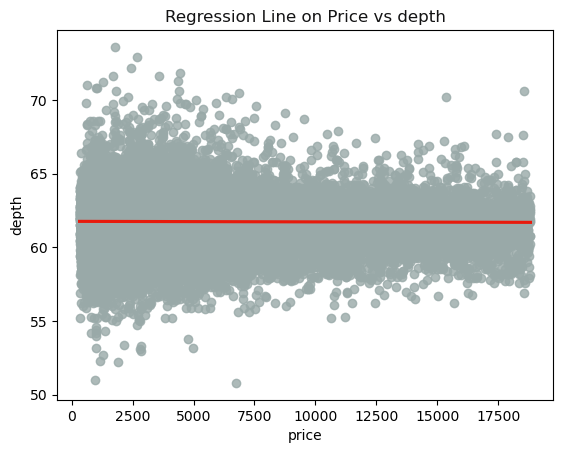

In [20]:
ax = sns.regplot(x="price", y="depth", data=data, fit_reg=True, scatter_kws={"color": "#99a9a8"}, line_kws={"color": "#e81a0c"})
ax.set_title("Regression Line on Price vs depth", color="#131314")

Text(0.5, 1.0, 'Regression Line on Price vs table')

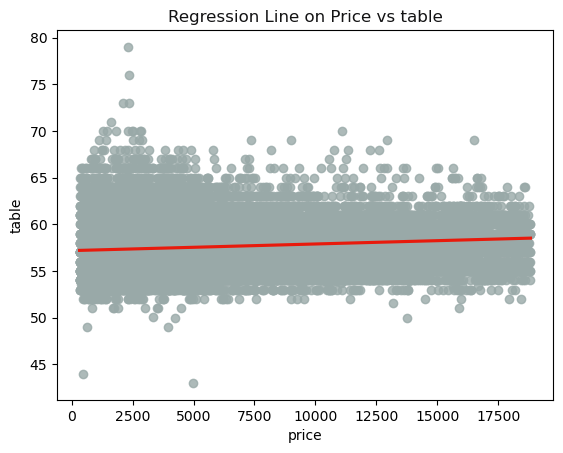

In [21]:
ax = sns.regplot(x="price", y="table", data=data, fit_reg=True, scatter_kws={"color": "#99a9a8"}, line_kws={"color": "#e81a0c"})
ax.set_title("Regression Line on Price vs table", color="#131314")

We have three categorical variables, which are cut, color, clarity.

Text(0.5, 0, 'Cut')

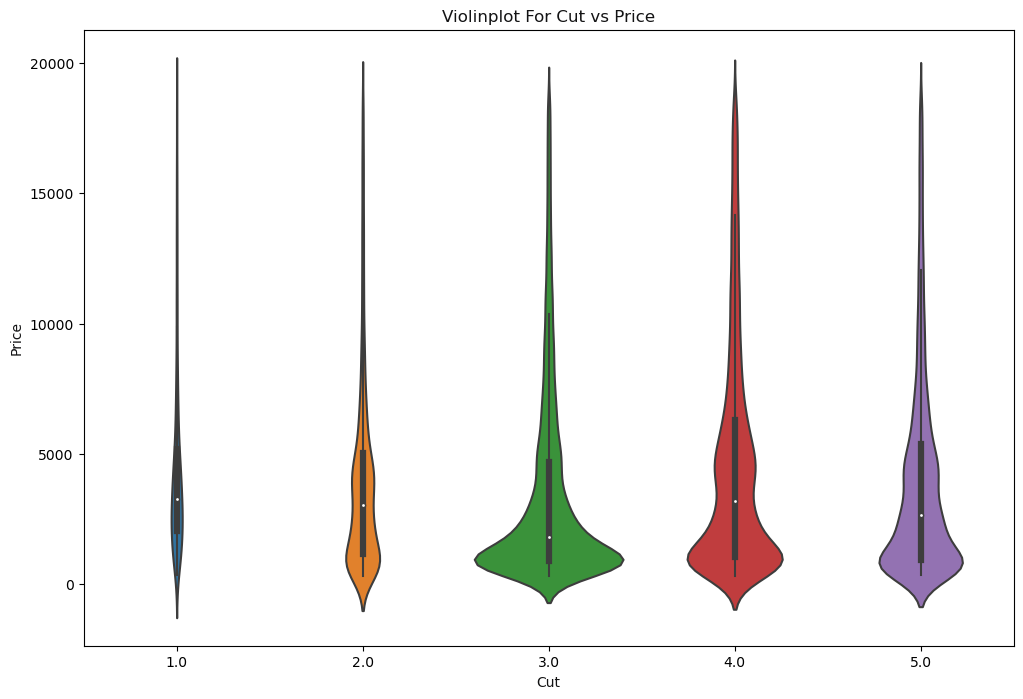

In [22]:
plt.figure(figsize=(12,8))
ax = sns.violinplot(x="cut",y="price", data=data, scale="count")
ax.set_title("Violinplot For Cut vs Price", color="#131314")
ax.set_ylabel("Price", color="#131314")
ax.set_xlabel("Cut", color="#131314")

Text(0.5, 0, 'color')

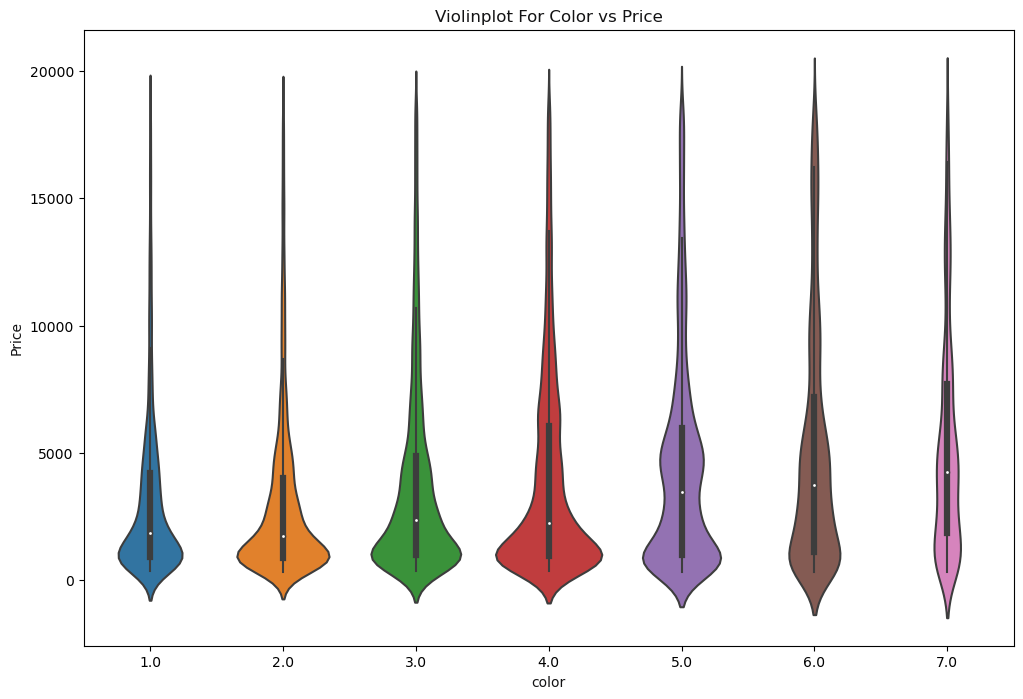

In [40]:
plt.figure(figsize=(12,8))
ax = sns.violinplot(x="color",y="price", data=data, scale="count")
ax.set_title("Violinplot For Color vs Price", color="#131314")
ax.set_ylabel("Price", color="#131314")
ax.set_xlabel("color", color="#131314")

Text(0.5, 0, 'clarity')

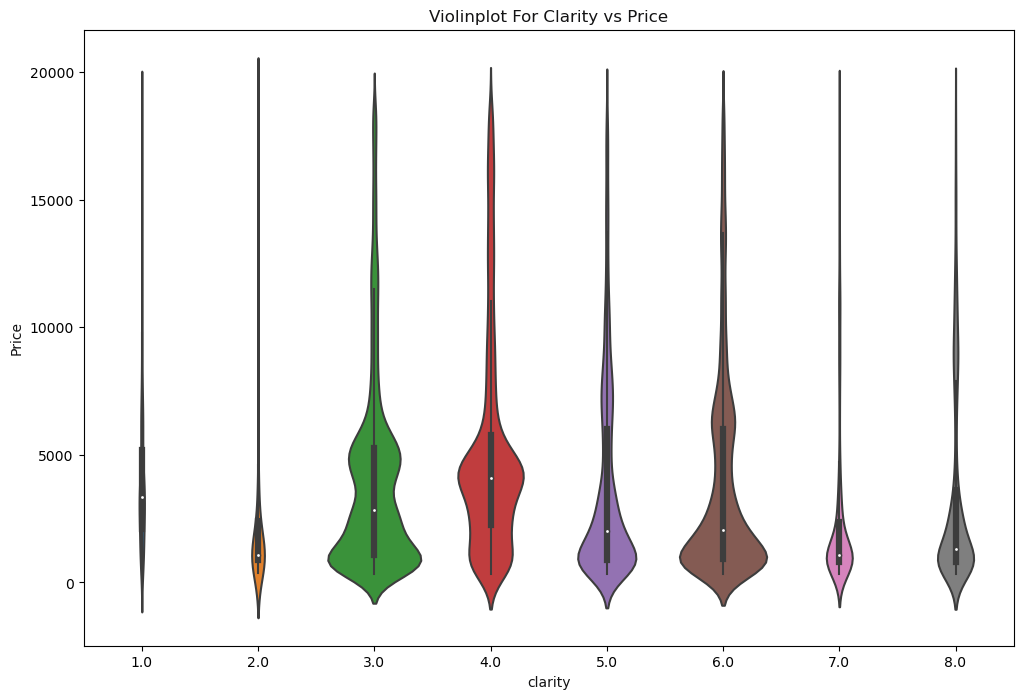

In [41]:
plt.figure(figsize=(12,8))
ax = sns.violinplot(x="clarity",y="price", data=data, scale="count")
ax.set_title("Violinplot For Clarity vs Price", color="#131314")
ax.set_ylabel("Price", color="#131314")
ax.set_xlabel("clarity", color="#131314")

From the above figures, we can see that
* "x", "y" and "z" show a high correlation to the target column, price. 
* "depth", "cut" and "table" show low correlation.

<h1 style='background:#6c8078; border:0; color:black'><center>Select variables</center></h1>

## 3 Select variables

We use Pearson Correlation for selecting variables
https://towardsdatascience.com/feature-selection-with-pandas-e3690ad8504b

<AxesSubplot:>

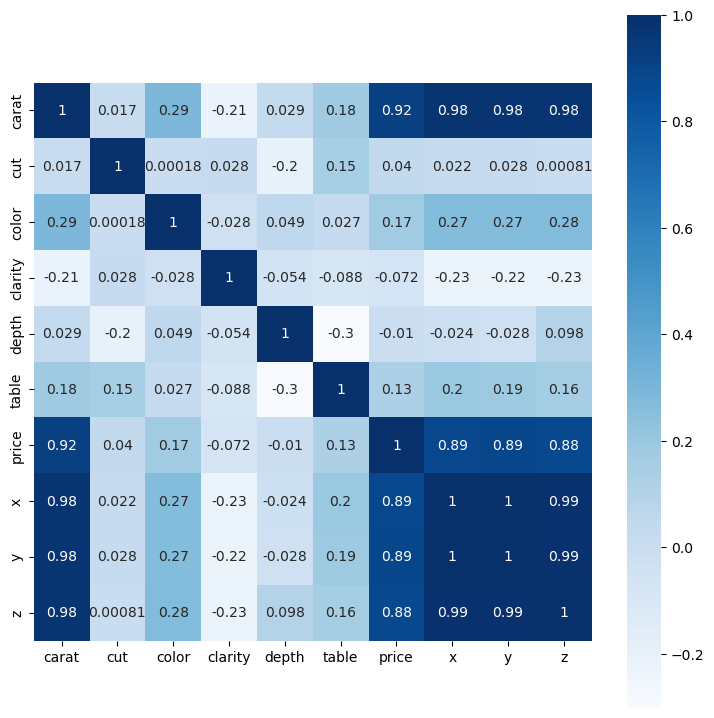

In [25]:
# calculate correlation coefficient
corr = data.corr()

# Set the size and background color
plt.subplots(figsize=(9,9),facecolor='w')

fig = sns.heatmap(corr, annot = True, vmax=1, square=True, cmap = "Blues", fmt = '.2g')

# Correlation plot 
fig

To see all correlations in more details, we will use built-in functions and level 0.5, as it looks sensible in our case.

In [26]:
# Correlation with dependent variable
y_corr = abs(corr["price"])

#Selecting highly correlated features
features = y_corr[y_corr >= 0.10]

features

carat    0.921590
color    0.172358
table    0.127108
price    1.000000
x        0.887212
y        0.888807
z        0.882634
Name: price, dtype: float64

In [27]:
data = data.drop(columns=['cut'])
data = data.drop(columns=['table'])
data = data.drop(columns=['depth'])

In [28]:
data.head()

,carat,color,clarity,price,x,y,z
0,0.23,2.0,4.0,326.0,3.95,3.98,2.43
1,0.21,2.0,3.0,326.0,3.89,3.84,2.31
2,0.23,2.0,5.0,327.0,4.05,4.07,2.31
3,0.29,6.0,6.0,334.0,4.20,4.23,2.63
4,0.31,7.0,4.0,335.0,4.34,4.35,2.75


<h1 style='background:#6c8078; border:0; color:black'><center>Model Building</center></h1>

## 4 Model Building

**Steps involved in Model Building**

* Setting up features and target
* Build a pipeline of standard scalar and model for five different regressors
* Fit all the models on training data
* Get mean of cross-validation on the training set for all the models for negative root mean square error
* Pick the model with the best cross-validation score
* Fit the best model on the training set and get

Split data into train and test data

In [29]:
# Assigning the featurs as X and trarget as y
X= data.drop(["price"], axis=1)
y= data["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)

print(f"No. of train data: {len(X_train)}")
print(f"No. of test data: {len(X_test)}")

No. of train data: 43125
No. of test data: 10782


### 4.1 Model 1 Decision Tree

In [50]:
model1 = DecisionTreeRegressor(ccp_alpha=0.0, 
                              criterion='mse', 
                              max_depth=2, # how many nodes
                              max_features=None, 
                              max_leaf_nodes=25,
                              min_impurity_decrease=0.0, 
                              min_samples_leaf=1, 
                              min_samples_split=2,
                              min_weight_fraction_leaf=0.0, 
                              random_state=None, 
                              splitter='best')

# model = DecisionTreeRegressor()
model1.fit(X_train, y_train)

# make predictions
expected_y  = y_test
predicted_y = model1.predict(X_test)

# summarize the fit of the model
print(metrics.r2_score(expected_y, predicted_y))
print(metrics.mean_squared_error(expected_y, predicted_y))

0.8247893771148007
2850586.5424103052


In [33]:
text_representation = tree.export_text(model1)
print(text_representation)

|--- feature_0 <= 1.00
|   |--- feature_0 <= 0.62
|   |   |--- value: [1046.53]
|   |--- feature_0 >  0.62
|   |   |--- value: [3062.58]
|--- feature_0 >  1.00
|   |--- feature_4 <= 7.19
|   |   |--- value: [6123.79]
|   |--- feature_4 >  7.19
|   |   |--- value: [12322.79]



### 4.2 Model 2 Random Forest

In [35]:
# Creat Random Forest model
from sklearn.ensemble import RandomForestRegressor

model2 = RandomForestRegressor(n_estimators = 10,
                                  ccp_alpha=0.0, 
                                  criterion='mse', 
                                  max_depth=5, # how many nodes
                                  max_features=None, 
                                  max_leaf_nodes=9,
                                  min_impurity_decrease=0.0, 
                                  min_samples_leaf=1, 
                                  min_samples_split=2,
                                  min_weight_fraction_leaf=0.0, 
                                  random_state= 25,
                                  bootstrap=True,
                                  oob_score=False,
                                  n_jobs=1)

# Fit model
model2.fit(X_train, y_train)

# Use cross validation
regressor_scores = cross_val_score(model2, X_train, y_train, cv = 10)

In [36]:
# calculate the value of r2 in the test data
print("Mean cross validation score: {}".format(np.mean(regressor_scores)))

Mean cross validation score: 0.905785790435327


In [47]:
# make predictions
expected_y  = y_test
predicted_y = model2.predict(X_test)

# summarize the fit of the model
print(metrics.r2_score(expected_y, predicted_y))
print(metrics.mean_squared_error(expected_y, predicted_y))

0.8959815934247803
1692325.870792464


### 4.3 Model 3 XGBRegressor

In [49]:
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

# creat Gradient Boosting model 
model3 = XGBRegressor(learning_rate=0.1, 
                    n_estimators=20, 
                    subsample=1.0, 
                    max_depth=5, 
                    init=None, 
                    random_state= 25, 
                    max_features=None, 
                    alpha=0.9, 
                    n_iter_no_change=None)

# fit model
model3.fit(X_train, y_train)

score = cross_val_score(model3, X_train, y_train, cv = 10).mean()
score

# make predictions
expected_y  = y_test
predicted_y = model3.predict(X_test)

# summarize the fit of the model
print(metrics.r2_score(expected_y, predicted_y))
print(metrics.mean_squared_error(expected_y, predicted_y))

0.9304450358654143
1131623.4224553427


<h1 style='background:#6c8078; border:0; color:black'><center>Results and Conclusions</center></h1>

## 5 Results and Conclusions

We used total three models, which are Regression Tree, Random Forest and XGBoost.
The results are as follow:
* Decision Tree **r2_score: 0.8247893771148007, mean_squared_error: 2,850,586.5424103052**.
* Random Forest **r2_score: 0.8959815934247803, mean_squared_error: 1,692,325.870792464**.
* XGBoost **r2_score: 0.9304450358654143, mean_squared_error: 1,131,623.4224553427**.

Obviously, XGBoost is the best model.

---**END**---